In [1]:
using JLD2, CairoMakie,Symbolics

CairoMakie.activate!()


In [2]:
nameConfigs = NamedTuple[]
push!(nameConfigs, (
    name = "convFD3",
    orderBtime = 1,
    orderBspace = -1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 0,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))


push!(nameConfigs, (
    name = "OPT2_staggeredlLike",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 2,
    pointsInTime = 1,
    supplementaryOrder = 0,
    fieldItpl = (
        ptsSpace = 2, ptsTime = 1,
        offsetSpace = 0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = -0.5, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))

push!(nameConfigs, (
    name = "convFD5",
    orderBtime = 1,
    orderBspace = -1,
    pointsInSpace = 5,
    pointsInTime = 1,
    supplementaryOrder = 0,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 2.0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
))


push!(nameConfigs, (
    name = "OPT3",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))


push!(nameConfigs, (
    name = "OPT3_nostag",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1/2, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))


push!(nameConfigs, (
    name = "OPT3_stag",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 5, ptsTime = 1,
        offsetSpace = 0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 1/2, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))


push!(nameConfigs, (
    name = "OPT3_stag_dense",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 9, ptsTime = 1,
        offsetSpace = 0, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 7, ptsTime = 1,
        offsetSpace = 1/4, offsetTime = 1,
        YorderBspace = 1, YorderBtime = 1,
    ),
))


push!(nameConfigs, (
    name = "OPT3_stag_3",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 1,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 9, ptsTime = 1,
        offsetSpace = 0, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 7, ptsTime = 1,
        offsetSpace = 1/4, offsetTime = 1,
        YorderBspace = 2, YorderBtime = 1,
    ),
))



8-element Vector{NamedTuple}:
 (name = "convFD3", orderBtime = 1, orderBspace = -1, pointsInSpace = 3, pointsInTime = 1, supplementaryOrder = 0, fieldItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 1.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1), materItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 1.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1))
 (name = "OPT2_staggeredlLike", orderBtime = 1, orderBspace = 1, pointsInSpace = 2, pointsInTime = 1, supplementaryOrder = 0, fieldItpl = (ptsSpace = 2, ptsTime = 1, offsetSpace = 0, offsetTime = 1, YorderBspace = 1, YorderBtime = 1), materItpl = (ptsSpace = 3, ptsTime = 1, offsetSpace = -0.5, offsetTime = 1, YorderBspace = 1, YorderBtime = 1))
 (name = "convFD5", orderBtime = 1, orderBspace = -1, pointsInSpace = 5, pointsInTime = 1, supplementaryOrder = 0, fieldItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 2.0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1), materItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 2.0

In [6]:
logsOfHinverse = [0.5*i for i in 0:6] #[1.0*i for i in 0:4]

cases=[]
#prefix="B"*string(tmpOrderBspace)*"_"*"w"*string(tmpWorderBspace)*"_"*string(tmpSupplementaryOrder)*"_"
prefix=""
L = 10.0*π
@variables x
∂ = Differential(x)
cases = push!(cases,(name=prefix*"homogeneous",u=cos(x),β=1.0))
cases = push!(cases,(name=prefix*"sameλ",u=cos(x),β=sin(x)+2))
cases = push!(cases,(name=prefix*"twiceλ",u=cos(x),β=sin(x/2) + 2))
cases = push!(cases,(name=prefix*"sameλ_shifted_π_3",u=cos(x),β=sin(x+π/3) + 2))
cases = push!(cases,(name=prefix*"λ_2",u=cos(x),β=cos(x).^2 + 1))
cases = push!(cases,(name=prefix*"quadratic",u=cos(x),β=x^2+ 1))


6-element Vector{Any}:
 (name = "homogeneous", u = cos(x), β = 1.0)
 (name = "sameλ", u = cos(x), β = 2 + sin(x))
 (name = "twiceλ", u = cos(x), β = 2 + sin((1//2)*x))
 (name = "sameλ_shifted_π_3", u = cos(x), β = 2 + sin(1.0471975511965976 + x))
 (name = "λ_2", u = cos(x), β = 1 + cos(x)^2)
 (name = "quadratic", u = cos(x), β = 1 + x^2)

In [17]:

data = load("/Users/nobuaki/Documents/Github/flexOPT/scripts/misfit_checkpoint_EGU_with_chelouOPT3.jld2")
misfit = data["misfit"]
done = data["done"]

@show nH, nCases, nConfigs = size(misfit)

normalisation=misfit[1,1,1]


(nH, nCases, nConfigs) = size(misfit) = (5, 3, 6)


0.01857020896065702

In [ ]:
logsOfHinverse = [0.5*i for i in 0:6] #[1.0*i for i in 0:4]

cases=[]
#prefix="B"*string(tmpOrderBspace)*"_"*"w"*string(tmpWorderBspace)*"_"*string(tmpSupplementaryOrder)*"_"
prefix=""
L = 10.0*π
@variables x
∂ = Differential(x)
cases = push!(cases,(name=prefix*"homogeneous",u=cos(x),β=1.0))
cases = push!(cases,(name=prefix*"sameλ",u=cos(x),β=sin(x)+2))
cases = push!(cases,(name=prefix*"twiceλ",u=cos(x),β=sin(x/2) + 2))
cases = push!(cases,(name=prefix*"sameλ_shifted_π_3",u=cos(x),β=sin(x+π/3) + 2))
cases = push!(cases,(name=prefix*"λ_2",u=cos(x),β=cos(x).^2 + 1))
cases = push!(cases,(name=prefix*"quadratic",u=cos(x),β=x^2+ 1))


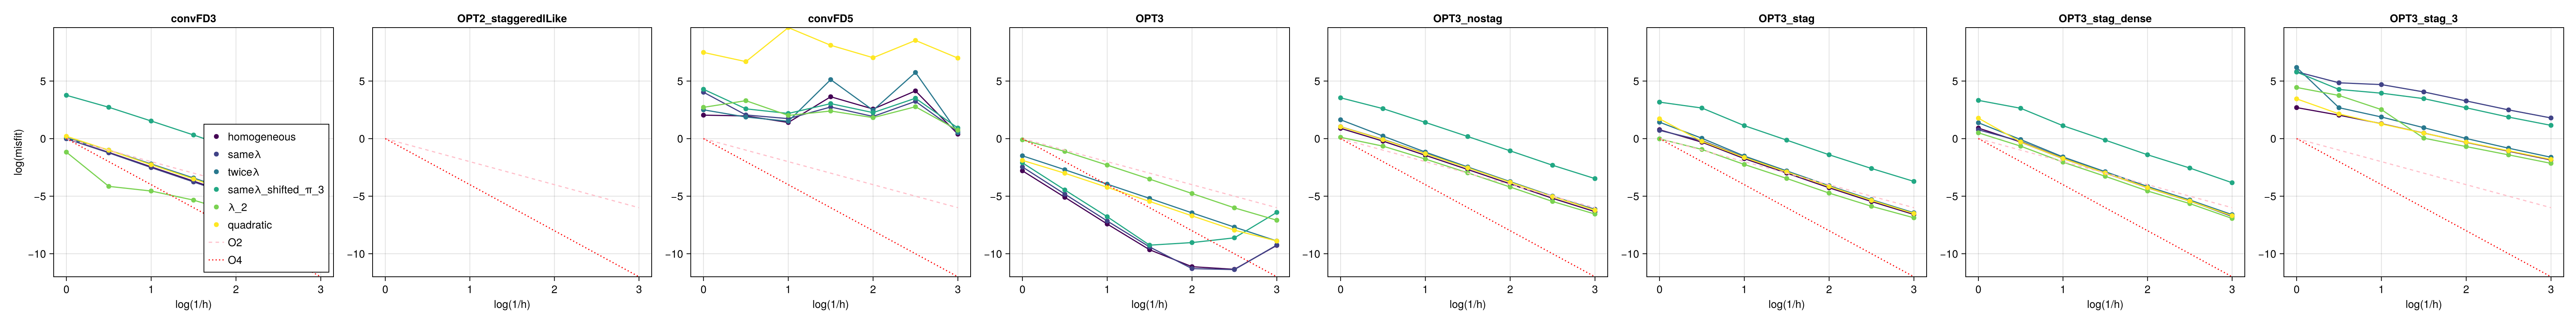

(nH, nCases, nConfigs) = size(misfit) = (7, 6, 8)


CairoMakie.Screen{IMAGE}


In [18]:

data = load("/Users/nobuaki/Documents/Github/flexOPT/scripts/misfit_checkpoint_EGU.jld2")
misfit = data["misfit"]
done = data["done"]

@show nH, nCases, nConfigs = size(misfit)

normalisation=misfit[1,1,1]



logmisfit = fill(NaN, size(misfit))
for iConfig in 1:nConfigs, iCase in 1:nCases, iH in 1:nH
    v = misfit[iH, iCase, iConfig]/normalisation
    if done[iH, iCase, iConfig] && isfinite(v) && v > 0
        logmisfit[iH, iCase, iConfig] = log(v)
    end
end

O2 = log.(1.0) .- 2.0 .* logsOfHinverse
O4 = log.(1.0) .- 4.0 .* logsOfHinverse

vals = filter(isfinite, vec(logmisfit))
ymin = minimum(vcat(vals, O2, O4))
ymax = maximum(vcat(vals, O2, O4))

fig = Figure(size = (420 * nConfigs, 420))
axes = Axis[]

N = length(cases)
colors = [get(Makie.colorschemes[:viridis], (i - 1) / max(N - 1, 1)) for i in 1:N]

for iConfig in (1:nConfigs)
    ax = Axis(
        fig[1, iConfig],
        title = nameConfigs[iConfig].name,
        xlabel = "log(1/h)",
        ylabel = iConfig == 1 ? "log(misfit)" : "",
    )
    push!(axes, ax)

    for iCase in 1:nCases
        y = logmisfit[:, iCase, iConfig]
        good = findall(isfinite, y)
        if !isempty(good)
            scatter!(ax, logsOfHinverse[good], y[good], color = colors[iCase], label = cases[iCase].name)
            lines!(ax, logsOfHinverse[good], y[good], color = colors[iCase])
        end
    end

    lines!(ax, logsOfHinverse, O2, color = :pink, linestyle = :dash, label = "O2")
    lines!(ax, logsOfHinverse, O4, color = :red, linestyle = :dot, label = "O4")
    ylims!(ax, ymin, ymax)
end

axislegend(axes[1], position = :rb)
display(fig)

In [10]:
save(fig,"tmp.png")

MethodError: MethodError: no method matching joinpath(::Figure)
The function `joinpath` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  joinpath(!Matched::Base.Filesystem.DirEntry, Any...)
   @ Base file.jl:1071
  joinpath(!Matched::AbstractString...)
   @ Base path.jl:346
  joinpath(!Matched::FilePathsBase.AbstractPath, Union{AbstractString, FilePathsBase.AbstractPath}...)
   @ FilePathsBase ~/.julia/packages/FilePathsBase/NV2We/src/aliases.jl:15
  ...


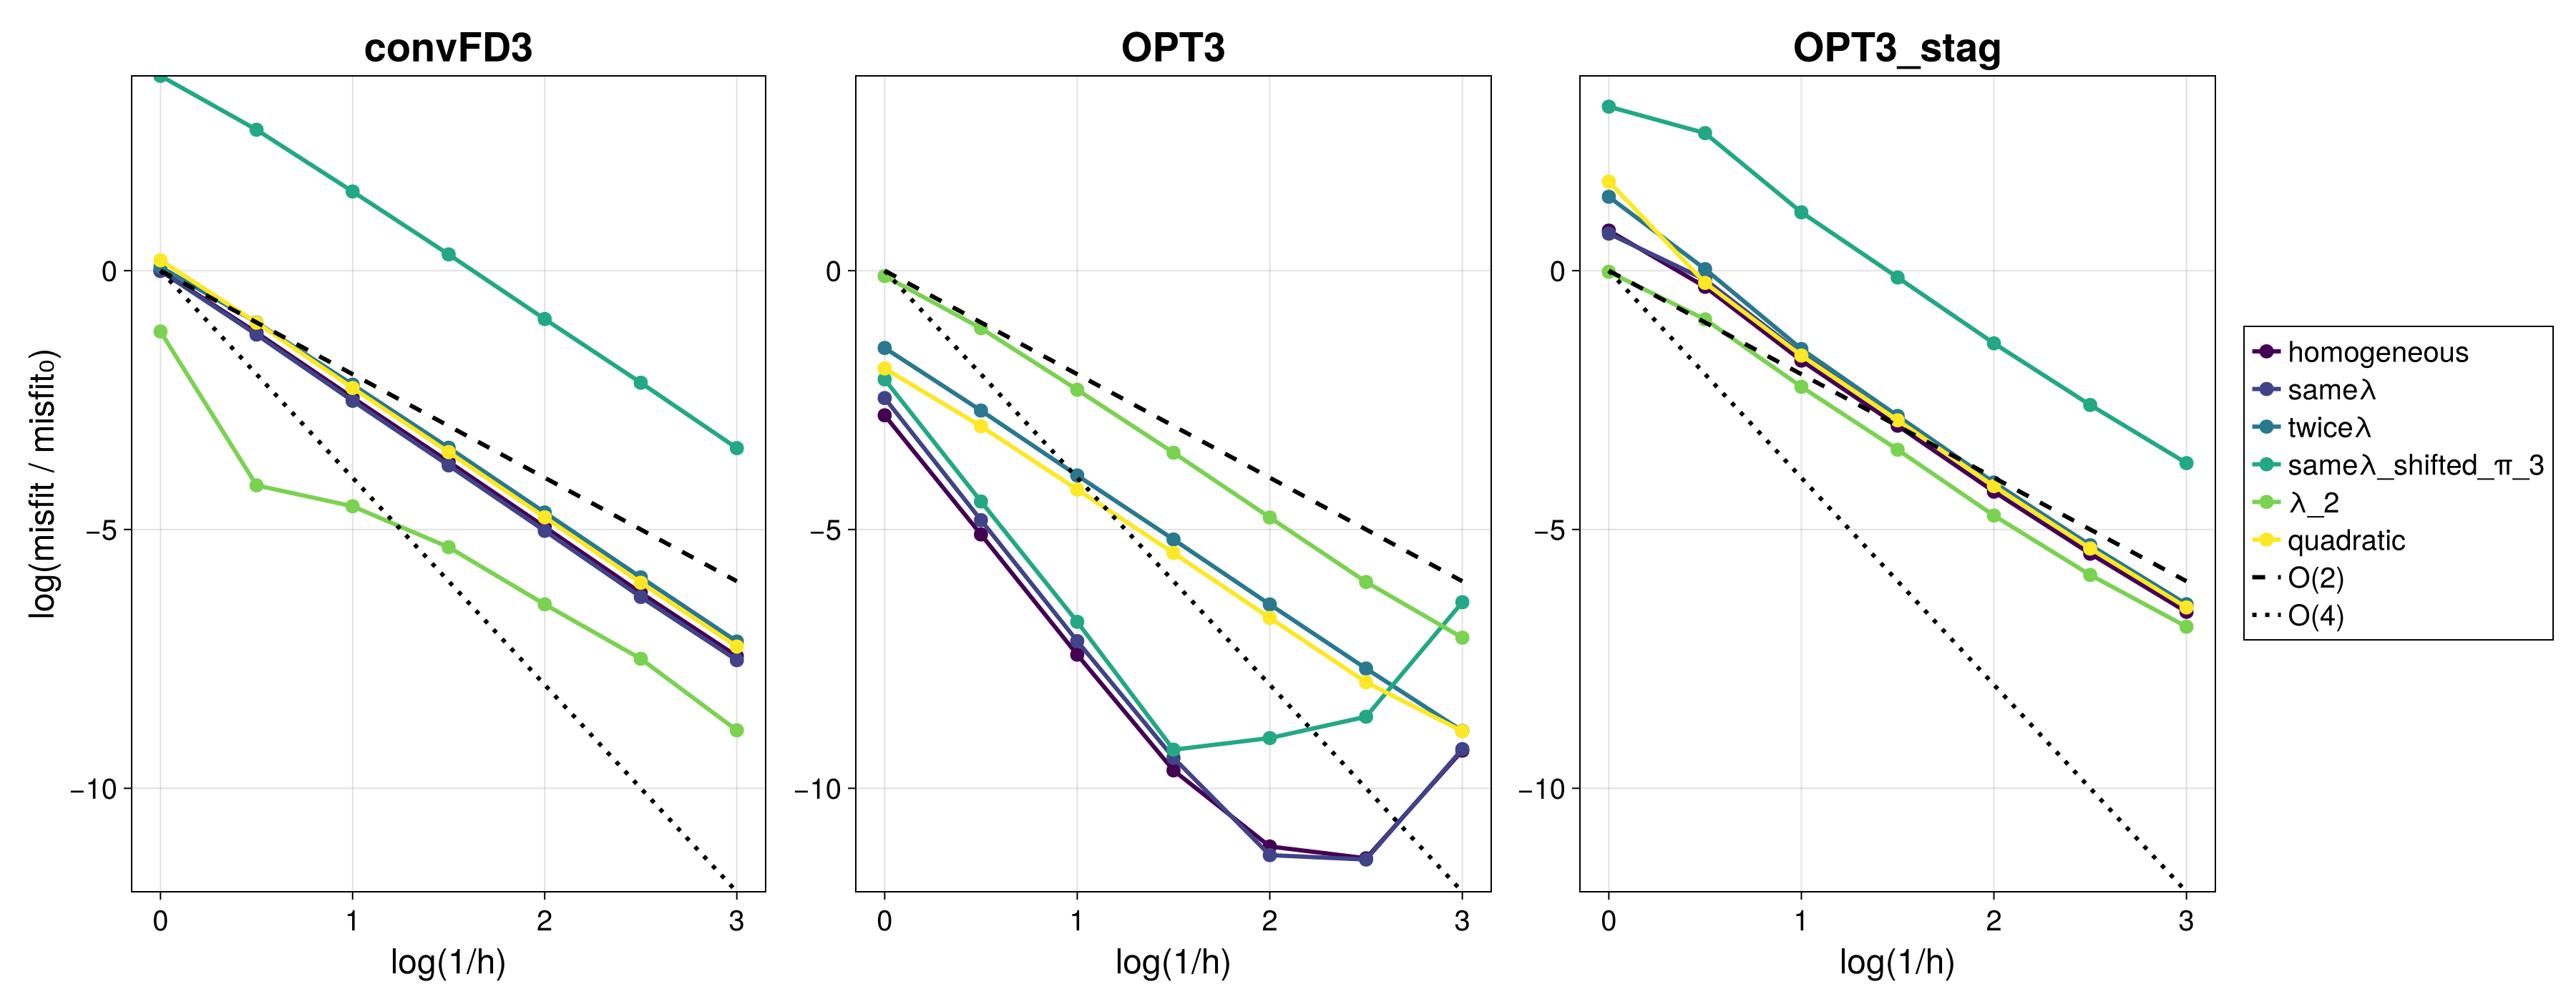

In [15]:
using CairoMakie

CairoMakie.activate!()

selected_configs = [1, 4, 6]
selected_names = nameConfigs[selected_configs]

logmisfit = fill(NaN, size(misfit))
for iConfig in 1:nConfigs, iCase in 1:nCases, iH in 1:nH
    v = misfit[iH, iCase, iConfig] / normalisation
    if done[iH, iCase, iConfig] && isfinite(v) && v > 0
        logmisfit[iH, iCase, iConfig] = log(v)
    end
end

O2 = log.(1.0) .- 2.0 .* logsOfHinverse
O4 = log.(1.0) .- 4.0 .* logsOfHinverse

vals = filter(isfinite, vec(logmisfit[:, :, selected_configs]))
ymin = minimum(vcat(vals, O2, O4))
ymax = maximum(vcat(vals, O2, O4))

N = length(cases)
colors = [get(Makie.colorschemes[:viridis], (i - 1) / max(N - 1, 1)) for i in 1:N]

fig = Figure(size = (1800, 700), fontsize = 24)
axes = Axis[]
legend_handles = Any[]

for (icol, iConfig) in enumerate(selected_configs)
    ax = Axis(
        fig[1, icol],
        title = nameConfigs[iConfig].name,
        xlabel = "log(1/h)",
        ylabel = icol == 1 ? "log(misfit / misfit₀)" : "",
        titlesize = 28,
        xlabelsize = 24,
        ylabelsize = 24,
        xticklabelsize = 20,
        yticklabelsize = 20,
    )
    push!(axes, ax)

    for iCase in 1:nCases
        y = logmisfit[:, iCase, iConfig]
        good = findall(isfinite, y)
        if !isempty(good)
            sc = scatter!(ax, logsOfHinverse[good], y[good], color = colors[iCase], markersize = 14)
            ln = lines!(ax, logsOfHinverse[good], y[good], color = colors[iCase], linewidth = 3)
            if icol == 1
                push!(legend_handles, [ln, sc] => cases[iCase].name)
            end
        end
    end

    l2 = lines!(ax, logsOfHinverse, O2, color = :black, linestyle = :dash, linewidth = 3)
    l4 = lines!(ax, logsOfHinverse, O4, color = :black, linestyle = :dot, linewidth = 3)

    if icol == 1
        push!(legend_handles, l2 => "O(2)")
        push!(legend_handles, l4 => "O(4)")
    end

    ylims!(ax, ymin, ymax)
end

leg = Legend(
    fig[1, 4],
    [h[1] for h in legend_handles],
    [h[2] for h in legend_handles],
    tellheight = false,
    tellwidth = true,
    labelsize = 20,
    titlesize = 22,
)

colgap!(fig.layout, 20)

display(fig)

save(
    "/Users/nobuaki/Documents/Github/flexOPT/scripts/misfit_poster.png",
    fig,
    px_per_unit = 3
)


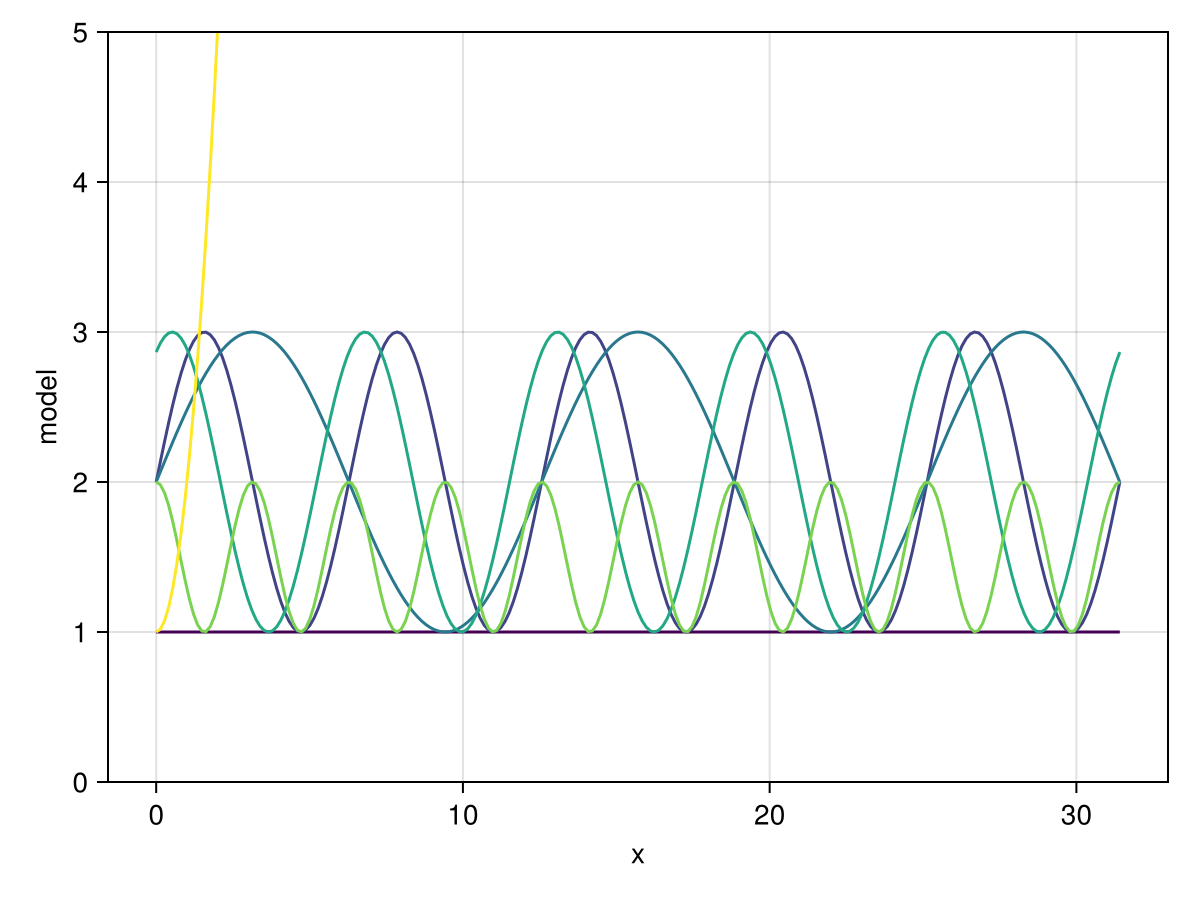

In [19]:

fig = Figure()
ax = Axis(fig[1, 1], xlabel="x", ylabel="model")
iH=5
for iCase ∈ eachindex(cases)
    name,_,β = cases[iCase]
    ΔxTry = exp(-logsOfHinverse[iH])
    Nx = Int(L÷ΔxTry) +1
    Δx = L/(Nx-1)
    X = [Δx * (i-1) for i ∈ range(1,Nx)]
    model=[Symbolics.value(substitute(β,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    lines!(ax, X, model, color=colors[iCase])
end
ylims!(ax, 0, 5)
display(fig)

save(
    "/Users/nobuaki/Documents/Github/flexOPT/scripts/models.png",
    fig,
    px_per_unit = 3
)
